In [1]:

import gfapy
import networkx as nx
import numpy as np
from itertools import product, combinations
from dimod import BQM
from dwave.system import LeapHybridSampler
from math import floor
import re
import matplotlib.pyplot as plt


In [2]:
def oriented_graph_from_file(filename):
    """Reads a .gfa file into an oriented graph.

    Args:
        filename (str): filepath to read.

    Returns:
        nx.Graph: corresponding oriented graph.
    """
    gfa = gfapy.Gfa.from_file(filename, vlevel=0)
    graph = nx.DiGraph()
    for segment_line in gfa.segments:
        graph.add_node(f'{segment_line.name}_+', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
        graph.add_node(f'{segment_line.name}_-', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
    for edge_line in gfa.edges:
        v1 = edge_line.sid1
        v2 = edge_line.sid2
        graph.add_edges_from([
            (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
        ])
        v1.invert()
        v2.invert()
        graph.add_edges_from([
            (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
        ])
    return graph

In [3]:
def normalise_node_weights(graph, normalisation):
    for node in graph.nodes:
        graph.nodes[node]["weight"] = round(graph.nodes[node]["weight"] / normalisation)
    return graph

In [4]:
g = oriented_graph_from_file('../../data/test.gfa')
# g = oriented_graph_from_file('../../data/ddDapMeze1.MT.k501.utg.final.gfa')
# g = normalise_node_weights(g, 100)

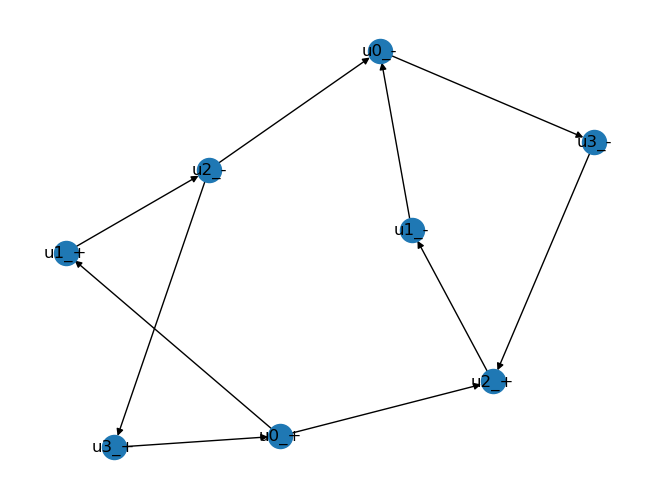

In [5]:
nx.draw_kamada_kawai(g, with_labels=True)

In [6]:
nodes = list(g.nodes)
V = int(len(nodes) / 2)
total_weight = int(sum(g.nodes[node]["weight"] for node in nodes) / 2)
alpha = 1.2
T_max = int(total_weight * alpha)

lambda_t = 1
lambda_g = 1
lambda_w = 1 

In [7]:
qubo_matrix = np.zeros((T_max, V + 1, 2, T_max, V + 1, 2))

# Path constraint
for t in range(T_max):
    for i in range(V):
        for b in range(2):
            qubo_matrix[t, i, b, t, i, b] -= lambda_t
            qubo_matrix[t, V, 0, t, i, b] += 2 * lambda_t
    qubo_matrix[t, V, 0, t, V, 0] -= lambda_t
    
    for i, j, bi, bj in product(range(V), range(V), range(2), range(2)):
        if not (i == j and bi == bj):
            qubo_matrix[t, i, bi, t, j, bj] += lambda_t

# Graph step constraints
for t in range(T_max - 1):
    for i, j, bi, bj in product(range(V), range(V), range(2), range(2)):
        if not (nodes[2 * i + bi], nodes[2 * j + bj]) in g.edges:
            qubo_matrix[t, i, bi, t+1, j, bj] += lambda_g
    for i, bi in product(range(V), range(2)):
        qubo_matrix[t, V, 0, t+1, i, bi] += lambda_g
            
# Weights constraints
for i in range(V):
    for t in range(T_max):
        for b in range(2):
            qubo_matrix[t, i, b, t, i, b] -= (2 * g.nodes[nodes[2 * i]]["weight"] - 1) * lambda_w
    
    for t1, t2 in product(range(T_max), range(T_max)):
        for b1, b2 in product(range(2), range(2)):
            if not (t1 == t2 and b1 == b2):
                qubo_matrix[t1, i, b1, t2, i, b2] += lambda_w


In [8]:

qubo_matrix = qubo_matrix.reshape((T_max * (V+1) * 2), (T_max * (V+1) * 2))
qubo_matrix = 0.5 * (qubo_matrix + qubo_matrix.T)

# Delete excess rows and columns
qubo_matrix = np.delete(qubo_matrix, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 0)
qubo_matrix = np.delete(qubo_matrix, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 1)

In [9]:
offset = lambda_t * T_max  + lambda_w * int(sum(g.nodes[nodes[2 * i]]["weight"] ** 2 for i in range(V)))
bqm = BQM(qubo_matrix, 'BINARY')
bqm.offset = offset
bqm.offset


13.0

In [10]:
print(bqm.num_variables)
print(bqm.num_interactions)
print(max(bqm.degrees().values()))
print(np.max(qubo_matrix))
print(np.min(qubo_matrix))

54
686
29
2.0
-4.0


In [32]:
# Upper bound for num interactions - TODO: not actually an UB
T_max * (2 + 6 * V + 4 * V ** 2 + 4 * T_max + len(g.edges))

45888

In [23]:
hybrid_sampler = LeapHybridSampler()
hybrid_sampleset = hybrid_sampler.sample(bqm, label="Oriented Tangle Testing")

In [313]:
hybrid_sample = hybrid_sampleset.first.sample
hybrid_energy = hybrid_sampleset.first.energy
hybrid_sample_list = np.array(list(hybrid_sample.values()))
hybrid_sample_list_copy = np.copy(hybrid_sample_list)
for idx in [t * (V+1) *2 + V * 2 + 1 for t in range(T_max)]:
    hybrid_sample_list_copy = np.insert(hybrid_sample_list_copy, idx, 0)
hybrid_sample_array = hybrid_sample_list_copy.reshape((T_max, V + 1, 2))

In [19]:
def array_to_path(arr):
    nz = np.nonzero(arr == 1)
    return [(nz[0][i], nz[1][i], nz[2][i]) for i in range(nz[0].shape[0])]
        

In [314]:
print(array_to_path(hybrid_sample_array))

[(0, 3, 1), (1, 1, 0), (2, 2, 1), (3, 2, 1), (4, 1, 1), (5, 0, 0)]
[(0, 0, 0), (1, 1, 0), (2, 2, 0), (3, 3, 0), (4, 0, 0), (5, 4, 0)]
[(0, 0, 0), (1, 1, 0), (2, 2, 0), (3, 3, 0), (4, 0, 0), (5, 4, 0)]


In [29]:
# k501 path
# best_path_nodes = ['u5-','u3-','u0-','u2+','u9+','u6-','u5+','u4-','u0-','u2+','u9+','u11+','u15+','u16+','u14-','u13-','u12+','u11-','u9-','u2-','u1+','u13-','u10-','u9-','u8+','u16-','u7-', 'u5-']

# k101 path
best_path_nodes = ["u21+","u23+","u25+","u27+","u39-","u30-","u29-","u24-","u23+","u25+","u0-","u2+","u3+","u6+","u10-","u37+","u5-","u3-","u2-","u1+","u11-","u12+","u14+","u38-","u16+","u35+","u32-","u33+","u34+","u40-","u7-","u3-","u2-","u1+","u36-","u35-","u20-","u18-","u17+","u39+","u26-","u23-","u21-","u19-","u18-","u15-","u38+","u13-","u12-","u9-","u37+","u8+","u29+","u31+","u40-","u4-","u3+","u6+","u28+","u33-","u22-"]


best_path_sample = np.zeros((T_max, V+1, 2))
for i in range(len(best_path_nodes)):
    node_matches = re.search(
        r'(.+)([\+\-])',
        best_path_nodes[i]
    )
    node_name = f"{node_matches[1]}_{node_matches[2]}"
    best_path_sample[i, floor(nodes.index(node_name) /2), nodes.index(node_name) % 2] = 1
best_path_sample[i+1:, -1, 0] = 1
print(array_to_path(best_path_sample))

[(0, 21, 0), (1, 23, 0), (2, 25, 0), (3, 27, 0), (4, 39, 1), (5, 30, 1), (6, 29, 1), (7, 24, 1), (8, 23, 0), (9, 25, 0), (10, 0, 1), (11, 2, 0), (12, 3, 0), (13, 6, 0), (14, 10, 1), (15, 37, 0), (16, 5, 1), (17, 3, 1), (18, 2, 1), (19, 1, 0), (20, 11, 1), (21, 12, 0), (22, 14, 0), (23, 38, 1), (24, 16, 0), (25, 35, 0), (26, 32, 1), (27, 33, 0), (28, 34, 0), (29, 40, 1), (30, 7, 1), (31, 3, 1), (32, 2, 1), (33, 1, 0), (34, 36, 1), (35, 35, 1), (36, 20, 1), (37, 18, 1), (38, 17, 0), (39, 39, 0), (40, 26, 1), (41, 23, 1), (42, 21, 1), (43, 19, 1), (44, 18, 1), (45, 15, 1), (46, 38, 0), (47, 13, 1), (48, 12, 1), (49, 9, 1), (50, 37, 0), (51, 8, 0), (52, 29, 0), (53, 31, 0), (54, 40, 1), (55, 4, 1), (56, 3, 0), (57, 6, 0), (58, 28, 0), (59, 33, 1), (60, 22, 1), (61, 41, 0), (62, 41, 0), (63, 41, 0), (64, 41, 0), (65, 41, 0), (66, 41, 0), (67, 41, 0), (68, 41, 0), (69, 41, 0), (70, 41, 0), (71, 41, 0), (72, 41, 0)]


In [30]:
best_sample = best_path_sample.reshape((T_max * (V+1) * 2),)
best_sample = np.delete(best_sample, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 0)


In [31]:
best_sample @ qubo_matrix @ best_sample

-403.0

In [27]:
offset = lambda_t * T_max  + lambda_w * int(sum(g.nodes[nodes[2 * i]]["weight"] ** 2 for i in range(V)))
offset

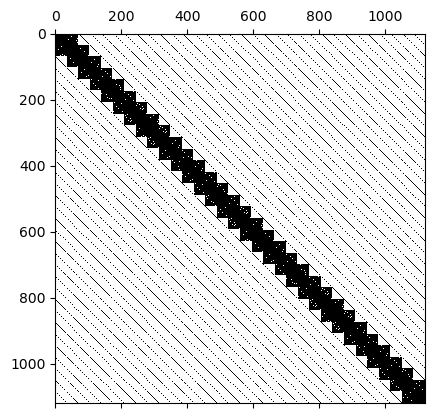

In [44]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.spy(qubo_matrix)
plt.show()


In [34]:
nz =np.nonzero(qubo_matrix)
len(nz[0])

173368

In [52]:
qubo_matrix.size

2916

In [53]:
2 ** qubo_matrix.shape[0]

18014398509481984

In [4]:
d = 5
samples = np.zeros((2 ** d, qubo_matrix.shape[0]))
for vars in product([0, 1], repeat=d):
    samples[0:d]

NameError: name 'qubo_matrix' is not defined

In [11]:
def binary_vectors_with_k_ones(m, k):
    # Create a list to store the valid binary vectors
    result = []
    
    # Loop over the possible number of 1's from 0 to k
    for num_ones in range(k + 1):
        # Get all combinations of positions for the 1's
        for ones_positions in combinations(range(m), num_ones):
            # Create a binary vector of length m with 0's
            vector = np.zeros(m, dtype=int)
            # Set the positions of the vector to 1 where the combination indicates
            vector[list(ones_positions)] = 1
            result.append(vector)
    
    # Convert the list of vectors into a NumPy array
    return np.array(result)

In [14]:
def binary_vectors_with_k_ones_batch(m, k, batch_size):
    batch = []
    for num_ones in range(k + 1):
        for ones_positions in combinations(range(m), num_ones):
            vector = np.zeros(m, dtype=int)
            vector[list(ones_positions)] = 1
            batch.append(vector)
            if len(batch) >= batch_size:
                yield np.array(batch)
                batch = []
    if batch:  # Yield the remaining vectors in the final batch
        yield np.array(batch)

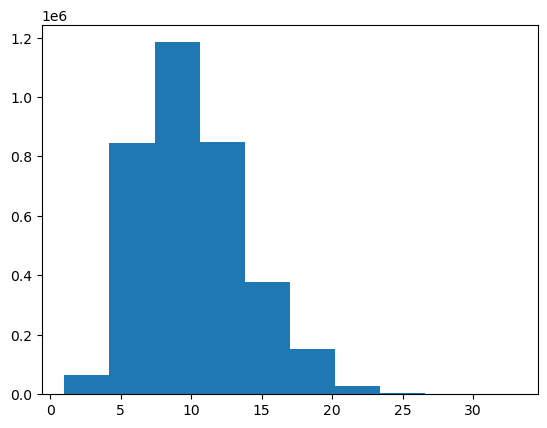

In [23]:
all_energies = np.array([])
for bins in binary_vectors_with_k_ones_batch(qubo_matrix.shape[0], 5, 100):
    energies = np.einsum("ij,ji->i", (bins @ qubo_matrix), bins.T) + offset
    all_energies = np.hstack((all_energies, energies))
    
plt.hist(all_energies)
plt.show()

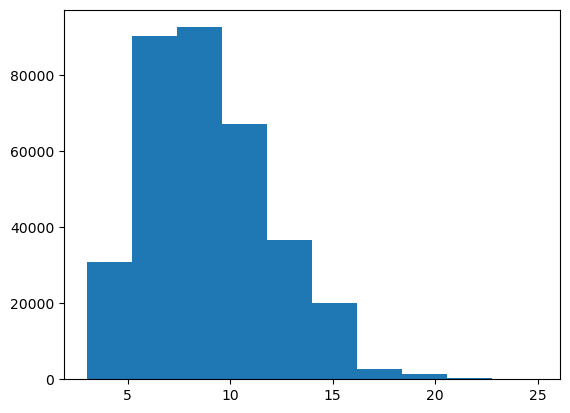

In [17]:
bins = binary_vectors_with_k_ones(qubo_matrix.shape[0], 4)

energies = np.einsum("ij,ji->i", (bins @ qubo_matrix), bins.T) + offset
plt.hist(energies)
plt.show()

In [18]:
all_energies[0]

array([13.,  9.,  9., 11., 11., 11., 11., 11., 11., 12.,  9.,  9., 11.,
       11., 11., 11., 11., 11., 12.,  9.,  9., 11., 11., 11., 11., 11.,
       11., 12.,  9.,  9., 11., 11., 11., 11., 11., 11., 12.,  9.,  9.,
       11., 11., 11., 11., 11., 11., 12.,  9.,  9., 11., 11., 11., 11.,
       11., 11., 12.,  9.,  9.,  9.,  9.,  9.,  9.,  9., 10.,  8.,  8.,
        7.,  8.,  7.,  8.,  8.,  8.,  8.,  7.,  7.,  7.,  7.,  7.,  7.,
        7.,  7.,  8.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  8.,  7.,
        7.,  7.,  7.,  7.,  7.,  7.,  7.,  8.,  7.])